In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv("income.csv")

In [3]:
df.shape

(22, 3)

In [4]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [5]:
from matplotlib import pyplot as plt

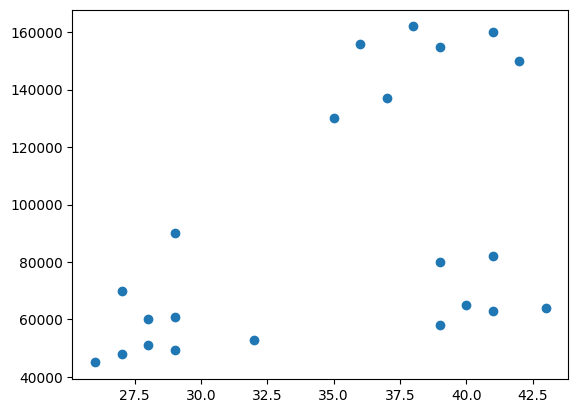

In [7]:
plt.scatter(df["Age"],df["Income($)"])
plt.show()

In [24]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,n_init='auto')
kmeans.fit(df[["Age","Income($)"]])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [13]:
kmeans.labels_

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
      dtype=int32)

In [14]:
df['Clusters']=kmeans.labels_

In [16]:
df.head()

,Name,Age,Income($),Clusters
0,Rob,27,70000,1
1,Michael,29,90000,2
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0


In [17]:
import  seaborn as sns

<Axes: xlabel='Age', ylabel='Income($)'>

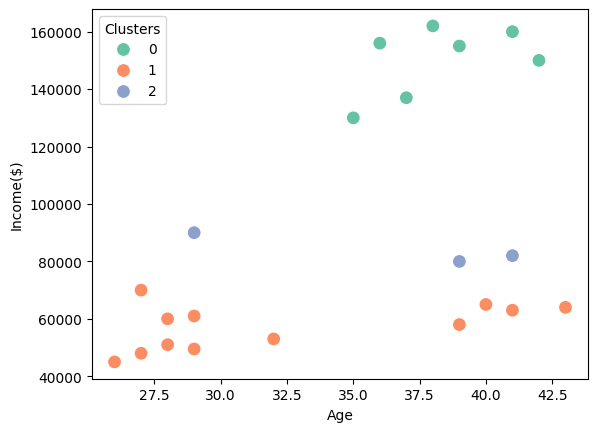

In [20]:
sns.scatterplot(df,x="Age",y="Income($)",palette="Set2",s=100,hue="Clusters")

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
columns=['Age','Income($)']
df[columns]=scaler.fit_transform(df[columns])

In [23]:
df.head()

,Name,Age,Income($),Clusters
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [25]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,n_init='auto')
kmeans.fit(df[["Age","Income($)"]])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [26]:
df['Clusters']=kmeans.labels_

In [27]:
df.head()

,Name,Age,Income($),Clusters
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [31]:
centroids=kmeans.cluster_centers_
centroids

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

<Axes: xlabel='Age', ylabel='Income($)'>

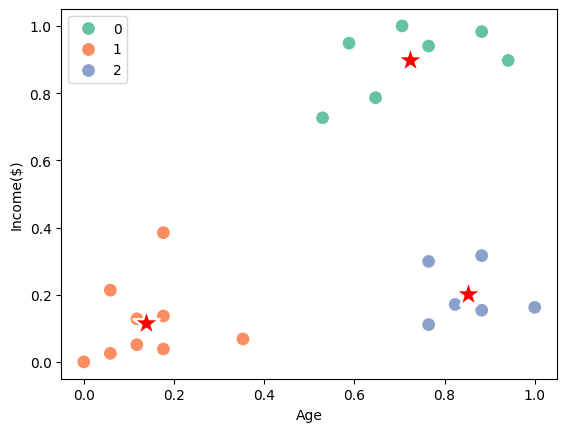

In [36]:
sns.scatterplot(df,x="Age",y="Income($)",palette="Set2",s=100,hue="Clusters")
sns.scatterplot(x=centroids[:,0],y=centroids[:,1],s=400,color='red',marker='*')

In [42]:
sse=[]
K_rng= range(1,10)
for k in K_rng:
    km=KMeans(n_clusters=k,n_init='auto')
    km.fit(df[["Age","Income($)"]])
    sse.append(km.inertia_)
sse

[5.434011511988179,
 2.4571335359046356,
 0.4750783498553096,
 0.36986589192348335,
 0.26640301246684156,
 0.21055478995472496,
 0.2199862072385215,
 0.14694455440063645,
 0.11190781744710707]

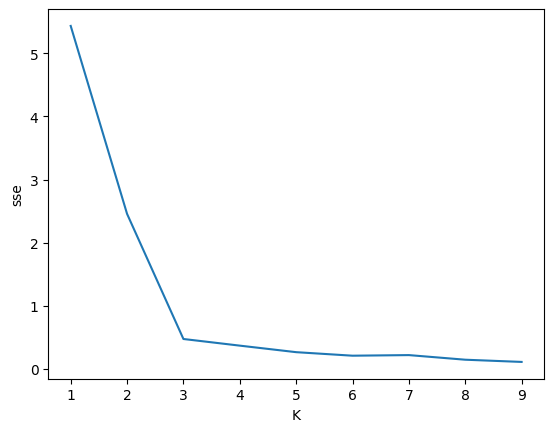

In [47]:
plt.plot(K_rng,sse)
plt.xlabel("K")
plt.ylabel("sse")
plt.show()